# Confidence-Score Based Sensor Fusion

Development notebook for building and validating an **innovation-based confidence-weighted sensor fusion** algorithm for the antenna pointing system.

The pipeline follows these steps:
1. **Data Generation** — Simulate realistic single-axis rotation driven by Brownian motion
2. **Sensor Modelling** — Add two sensors (Encoder & AHRS) with distinct noise profiles
3. **Confidence Scoring** — Compute per-sensor confidence using dynamic variance and drift penalty
4. **Sensor Fusion** — Direct confidence-weighted angle fusion in the 1D domain
5. **Final Preview** — Evaluate and visualize the full fusion pipeline

---
## 1. Data Generation & Environment

We generate a realistic single-axis rotation trajectory. The antenna starts at 0° and moves
within the range **[-90°, +90°]**.

The **angular velocity** evolves as a **Brownian motion** (Wiener process) with light damping,
and the angle is obtained by integrating that velocity. Reflective boundaries at ±90° keep
the trajectory within physical limits.

$$\omega(t + \Delta t) = \alpha \cdot \omega(t) + \sigma_{BM} \sqrt{\Delta t} \cdot \mathcal{N}(0,1)$$

$$\theta(t + \Delta t) = \theta(t) + \omega(t) \cdot \Delta t$$

where $\alpha = 0.998$ is a damping coefficient that prevents runaway velocities.

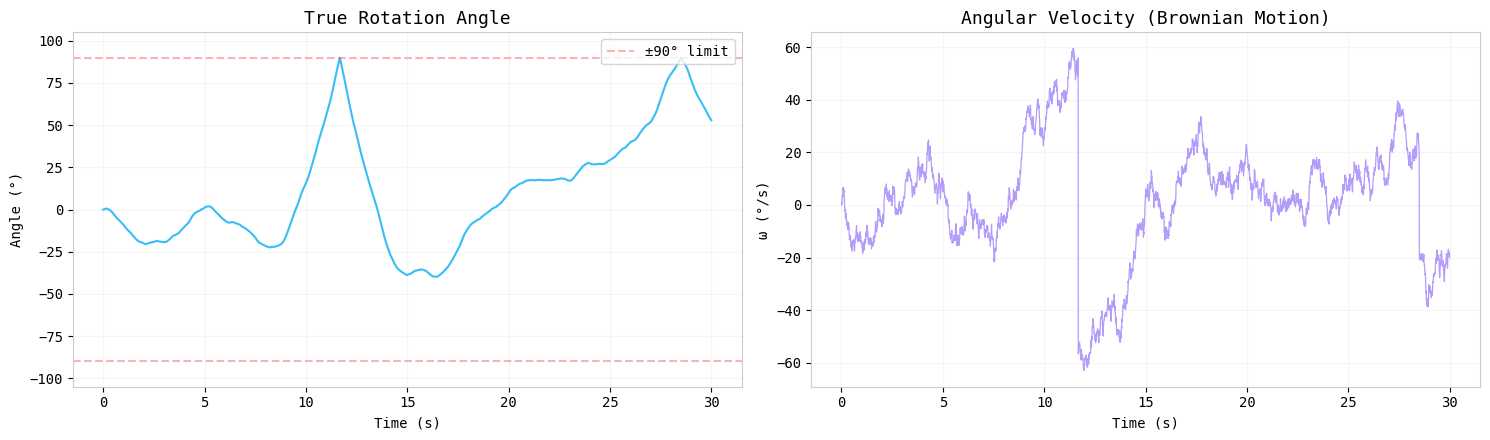

Duration: 30.0s  |  Samples: 3000  |  dt: 0.01s
Angle range: [-39.8°, 90.0°]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ── Plotting style ────────────────────────────────────────────────────────
plt.style.use('default')
rcParams['font.family'] = 'monospace'
rcParams['axes.edgecolor'] = '#cccccc'
rcParams['axes.facecolor'] = '#ffffff'
rcParams['figure.facecolor'] = '#ffffff'

# ── Simulation parameters ─────────────────────────────────────────────────
np.random.seed(42)
dt       = 0.01       # Time step (s)
T        = 30.0       # Total duration (s)
N        = int(T / dt)
t        = np.linspace(0, T, N)

sigma_bm = 15.0       # Brownian motion volatility (°/s per √s)
alpha    = 0.998       # Damping coefficient
ANGLE_LIMIT = 90.0    # ±90° boundaries

# ── Generate trajectory via Brownian motion ──────────────────────────────
omega      = np.zeros(N)   # Angular velocity (°/s)
theta_true = np.zeros(N)   # True angle (°)

for i in range(1, N):
    # Brownian step on angular velocity with damping
    omega[i] = alpha * omega[i-1] + sigma_bm * np.sqrt(dt) * np.random.randn()

    # Integrate velocity → angle
    theta_true[i] = theta_true[i-1] + omega[i] * dt

    # Reflective boundaries at ±90°
    if theta_true[i] > ANGLE_LIMIT:
        theta_true[i] = 2 * ANGLE_LIMIT - theta_true[i]
        omega[i] = -abs(omega[i])
    elif theta_true[i] < -ANGLE_LIMIT:
        theta_true[i] = -2 * ANGLE_LIMIT - theta_true[i]
        omega[i] = abs(omega[i])

# ── Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

axes[0].plot(t, theta_true, color='#38bdf8', linewidth=1.5)
axes[0].axhline(y= ANGLE_LIMIT, color='#ef4444', ls='--', alpha=0.4, label='±90° limit')
axes[0].axhline(y=-ANGLE_LIMIT, color='#ef4444', ls='--', alpha=0.4)
axes[0].set_title('True Rotation Angle', fontsize=13)
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Angle (°)')
axes[0].set_ylim(-105, 105)
axes[0].legend(loc='upper right'); axes[0].grid(alpha=0.12)

axes[1].plot(t, omega, color='#a78bfa', linewidth=0.9, alpha=0.85)
axes[1].set_title('Angular Velocity (Brownian Motion)', fontsize=13)
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('ω (°/s)')
axes[1].grid(alpha=0.12)

plt.tight_layout()
plt.show()

print(f'Duration: {T}s  |  Samples: {N}  |  dt: {dt}s')
print(f'Angle range: [{theta_true.min():.1f}°, {theta_true.max():.1f}°]')

---
## 2. Sensor Readings & Noise

We model **two independent sensors** measuring the same rotation:

| Sensor  | Characteristic | Noise Model |
|---------|---------------|-------------|
| **Encoder** | High precision, but susceptible to occasional drift | $\theta_{enc} = \theta_{true} + \mathcal{N}(0, \sigma_{enc}) + \text{drift}(t)$ |
| **AHRS**    | Noisier overall, but drift-free | $\theta_{ahrs} = \theta_{true} + \mathcal{N}(0, \sigma_{ahrs})$ |

The encoder has a **lower base noise** ($\sigma_{enc} = 1.5°$) but experiences **two drift events** during
the simulation. The AHRS has a **higher base noise** ($\sigma_{ahrs} = 5.0°$) but remains consistently unbiased.

This asymmetry is what makes the confidence-weighted fusion valuable — the algorithm should
automatically trust each sensor more during its reliable periods.

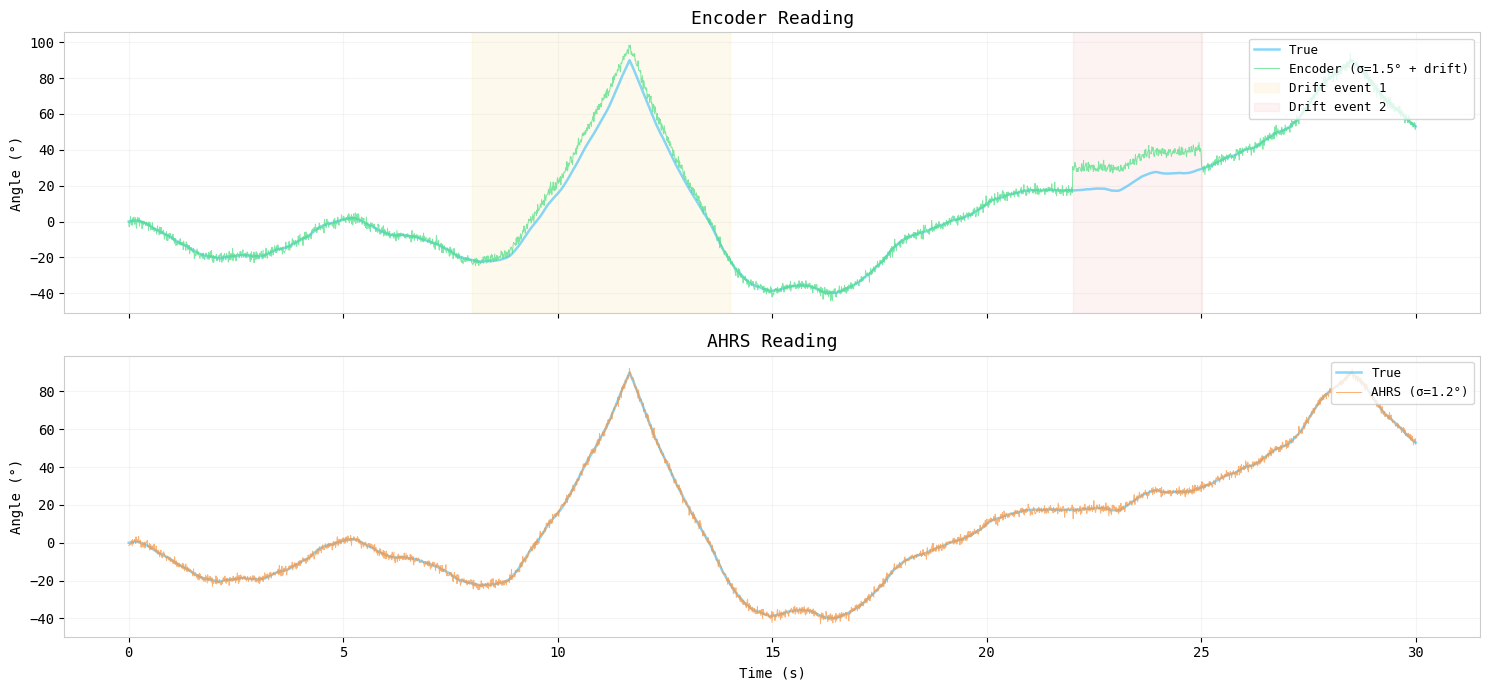

In [2]:
# ── Sensor noise parameters ───────────────────────────────────────────────
sigma_enc  = 1.5    # Encoder base noise σ (°)
sigma_ahrs = 1.2    # AHRS base noise σ (°)

# ── Encoder drift profile ─────────────────────────────────────────────────
# Simulates two real-world failure modes:
#   1) Gradual drift (mechanical slip)   → samples 800–1400
#   2) Sudden offset (electrical glitch) → samples 2200–2500
drift_enc = np.zeros(N)
# Event 1: gradual drift up to 10° and back
ramp_up   = np.linspace(0, 10, 300)
ramp_down = np.linspace(10, 0, 300)
drift_enc[800:1100]  = ramp_up
drift_enc[1100:1400] = ramp_down
# Event 2: sudden offset of 12°
drift_enc[2200:2500] = 12.0

# ── Generate noisy sensor readings ────────────────────────────────────────
noise_enc  = np.random.normal(0, sigma_enc,  N)
noise_ahrs = np.random.normal(0, sigma_ahrs, N)

theta_enc  = theta_true + noise_enc + drift_enc
theta_ahrs = theta_true + noise_ahrs

# ── Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

axes[0].plot(t, theta_true, color='#38bdf8', lw=1.8, label='True', alpha=0.6)
axes[0].plot(t, theta_enc,  color='#4ade80', lw=0.7, alpha=0.7,
             label=f'Encoder (σ={sigma_enc}° + drift)')
# Highlight drift regions
axes[0].axvspan(t[800],  t[1400], alpha=0.08, color='#fbbf24', label='Drift event 1')
axes[0].axvspan(t[2200], t[2500], alpha=0.08, color='#f87171', label='Drift event 2')
axes[0].set_title('Encoder Reading', fontsize=13)
axes[0].set_ylabel('Angle (°)')
axes[0].legend(loc='upper right', fontsize=9); axes[0].grid(alpha=0.12)

axes[1].plot(t, theta_true, color='#38bdf8', lw=1.8, label='True', alpha=0.6)
axes[1].plot(t, theta_ahrs, color='#fb923c', lw=0.7, alpha=0.7,
             label=f'AHRS (σ={sigma_ahrs}°)')
axes[1].set_title('AHRS Reading', fontsize=13)
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Angle (°)')
axes[1].legend(loc='upper right', fontsize=9); axes[1].grid(alpha=0.12)

plt.tight_layout()
plt.show()

---
## 3. Confidence Scoring (Innovation-Based Inverse Variance)

Rather than penalizing both sensors symmetrically using a cross-sensor mean, we employ an
**Innovation-Based Inverse Variance** weighting scheme with targeted drift penalty.

### 1. Prior Baseline Noise
Each sensor has an established baseline noise variance from its specification:
$$\sigma_{prior, enc} = 1.5^\circ, \quad \sigma_{prior, ahrs} = 1.2^\circ$$

### 2. Detrended Dynamic Variance
A causal sliding window measures real-time noise variance $\sigma_i^2$ over window $W = 50$ samples.

**Critical detail:** The variance is computed on *detrended* data within each window. A linear
trend is fitted and subtracted before computing variance. This isolates the sensor noise
characteristics from the physical trajectory motion, which would otherwise dominate the
variance estimate (raw trajectory variance ≈ 12°² vs actual noise variance ≈ 2°²).

$$\sigma_{i,dyn}^2(t) = \text{Var}\big[\theta_i(t-W+1:t) - \text{LinearFit}(t-W+1:t)\big]$$

### 3. Divergence & Drift Detection
The cross-sensor innovation (divergence) is:
$$\Delta\theta(t) = \theta_{enc}(t) - \theta_{ahrs}(t)$$

Because AHRS is drift-free, any sustained divergence trend indicates encoder drift. We filter
$\Delta\theta(t)$ with a causal moving average to isolate low-frequency drift from zero-mean Gaussian noise:
$$d_{trend}(t) = \frac{1}{W} \sum_{k=0}^{W-1} \Delta\theta(t - k)$$

A selective penalty is applied to the drifting sensor:
$$\text{drift\_penalty}_{enc}(t) = 5.0 \cdot |d_{trend}(t)|, \quad \text{drift\_penalty}_{ahrs} = 0$$

### 4. Inverse Variance Weighting
Raw confidence scores are computed via inverse variance:
$$c_{enc}^{raw} = \frac{1}{\sigma_{prior, enc}^2 + \sigma_{enc,dyn}^2 + \text{drift\_penalty}_{enc} + 10^{-5}}$$
$$c_{ahrs}^{raw} = \frac{1}{\sigma_{prior, ahrs}^2 + \sigma_{ahrs,dyn}^2 + 10^{-5}}$$

Normalized weights ensure $c_{enc} + c_{ahrs} = 1$:
$$c_i = \frac{c_i^{raw}}{c_{enc}^{raw} + c_{ahrs}^{raw}}$$

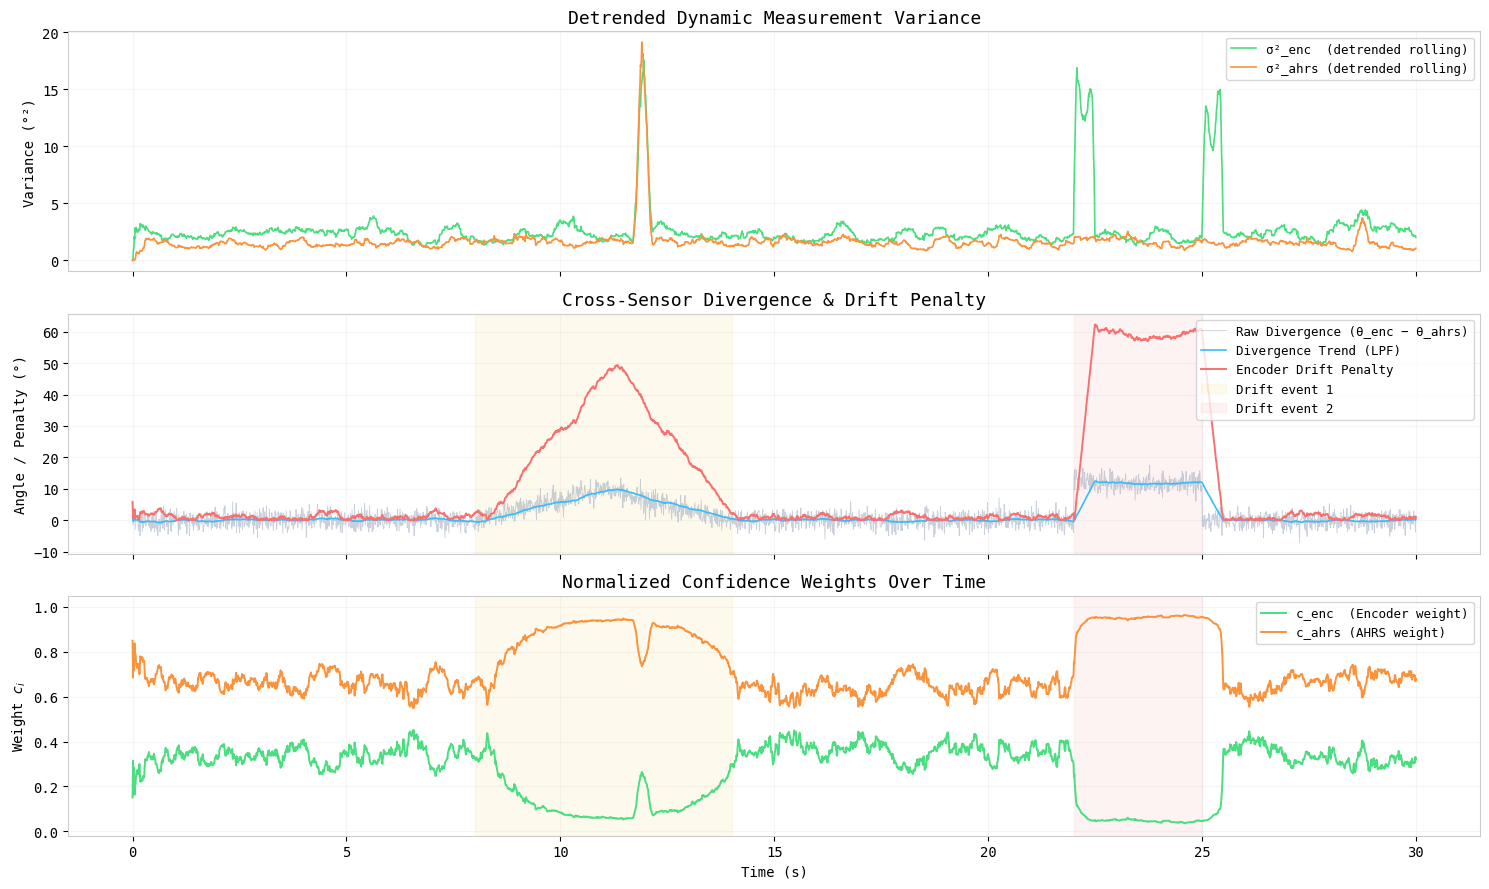

Mean confidence — Encoder: 0.2695  |  AHRS: 0.7305


In [3]:
# ── Prior noise parameters ────────────────────────────────────────────────
sigma_prior_enc  = 1.5   # Encoder prior baseline noise σ (°)
sigma_prior_ahrs = 1.2   # AHRS prior baseline noise σ (°)

# ── Detrended dynamic variance (causal rolling variance) ──────────────────
WINDOW = 50  # samples (= 0.5 s at 100 Hz)

def rolling_variance(data, window):
    """Compute rolling variance on *detrended* data within a causal window.

    A linear trend is fitted and subtracted within each window before
    computing variance. This isolates sensor noise from the physical
    trajectory motion, which would otherwise dominate the estimate.
    """
    n = len(data)
    var = np.zeros(n)
    for i in range(n):
        start = max(0, i - window + 1)
        segment = data[start:i+1]
        seg_len = len(segment)
        if seg_len < 3:
            var[i] = 0.0
        else:
            x = np.arange(seg_len)
            coeffs = np.polyfit(x, segment, 1)
            detrended = segment - np.polyval(coeffs, x)
            var[i] = np.var(detrended)
    return var

var_enc  = rolling_variance(theta_enc,  WINDOW)
var_ahrs = rolling_variance(theta_ahrs, WINDOW)

# ── Sensor divergence & drift penalty ─────────────────────────────────────
divergence = theta_enc - theta_ahrs

# Causal rolling mean low-pass filter to extract drift trend
divergence_trend = np.zeros(N)
for i in range(N):
    start = max(0, i - WINDOW + 1)
    divergence_trend[i] = np.mean(divergence[start:i+1])

drift_penalty_enc  = np.abs(divergence_trend) * 5.0
drift_penalty_ahrs = 0.0

# ── Inverse variance confidence scoring ───────────────────────────────────
c_enc_raw  = 1.0 / (sigma_prior_enc**2  + var_enc  + drift_penalty_enc  + 1e-5)
c_ahrs_raw = 1.0 / (sigma_prior_ahrs**2 + var_ahrs + drift_penalty_ahrs + 1e-5)

# Normalized weights (c_enc + c_ahrs = 1)
c_enc  = c_enc_raw  / (c_enc_raw + c_ahrs_raw)
c_ahrs = c_ahrs_raw / (c_enc_raw + c_ahrs_raw)

# ── Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)

# Panel 1: Rolling variance
axes[0].plot(t, var_enc,  color='#4ade80', lw=1.2, label='σ²_enc  (detrended rolling)')
axes[0].plot(t, var_ahrs, color='#fb923c', lw=1.2, label='σ²_ahrs (detrended rolling)')
axes[0].set_title('Detrended Dynamic Measurement Variance', fontsize=13)
axes[0].set_ylabel('Variance (°²)')
axes[0].legend(loc='upper right', fontsize=9); axes[0].grid(alpha=0.12)

# Panel 2: Divergence and drift penalty
axes[1].plot(t, divergence, color='#94a3b8', lw=0.6, alpha=0.5, label='Raw Divergence (θ_enc − θ_ahrs)')
axes[1].plot(t, divergence_trend, color='#38bdf8', lw=1.2, label='Divergence Trend (LPF)')
axes[1].plot(t, drift_penalty_enc, color='#f87171', lw=1.4, label='Encoder Drift Penalty')
axes[1].axvspan(t[800],  t[1400], alpha=0.08, color='#fbbf24', label='Drift event 1')
axes[1].axvspan(t[2200], t[2500], alpha=0.08, color='#f87171', label='Drift event 2')
axes[1].set_title('Cross-Sensor Divergence & Drift Penalty', fontsize=13)
axes[1].set_ylabel('Angle / Penalty (°)')
axes[1].legend(loc='upper right', fontsize=9); axes[1].grid(alpha=0.12)

# Panel 3: Normalized confidence weights
axes[2].plot(t, c_enc,  color='#4ade80', lw=1.4, label='c_enc  (Encoder weight)')
axes[2].plot(t, c_ahrs, color='#fb923c', lw=1.4, label='c_ahrs (AHRS weight)')
axes[2].axvspan(t[800],  t[1400], alpha=0.08, color='#fbbf24')
axes[2].axvspan(t[2200], t[2500], alpha=0.08, color='#f87171')
axes[2].set_title('Normalized Confidence Weights Over Time', fontsize=13)
axes[2].set_xlabel('Time (s)'); axes[2].set_ylabel('Weight $c_i$')
axes[2].set_ylim(-0.02, 1.05)
axes[2].legend(loc='upper right', fontsize=9); axes[2].grid(alpha=0.12)

plt.tight_layout()
plt.show()

print(f'Mean confidence — Encoder: {c_enc.mean():.4f}  |  AHRS: {c_ahrs.mean():.4f}')

---
## 4. Direct Confidence-Weighted Angle Fusion

For a single-axis rotation $[-90^\circ, +90^\circ]$, 3D quaternion transformations are unnecessary:
- Single-axis 1D rotation has no gimbal lock or spatial singularities.
- Converting angles to quaternions, averaging, and mapping back via `arctan2` introduces non-linear distortion and unnecessary computational overhead.

The optimal fused angle is computed directly in the angle domain via vectorized weighted sum:

$$\theta_{fused} = c_{enc} \cdot \theta_{enc} + c_{ahrs} \cdot \theta_{ahrs}$$

Since $c_{enc} + c_{ahrs} = 1$, this represents a valid convex combination of sensor estimates.

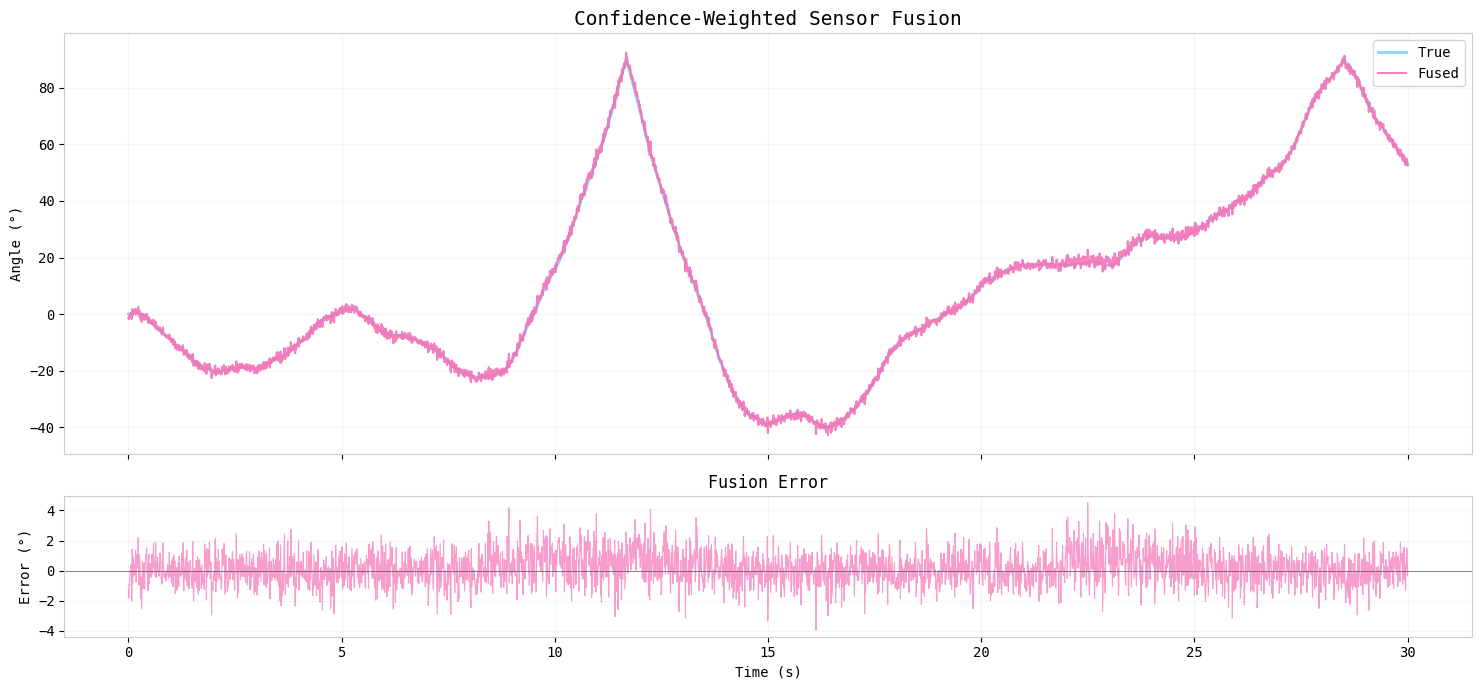

RMSE  Encoder : 4.794°
RMSE  AHRS    : 1.231°
RMSE  Fused   : 1.071°
Improvement over Encoder : +77.6%
Improvement over AHRS    : +13.0%


In [4]:
# ── Direct 1D confidence-weighted angle fusion ────────────────────────────
theta_fused = c_enc * theta_enc + c_ahrs * theta_ahrs

# ── Error analysis ────────────────────────────────────────────────────────
err_enc   = theta_enc   - theta_true
err_ahrs  = theta_ahrs  - theta_true
err_fused = theta_fused - theta_true

rmse_enc   = np.sqrt(np.mean(err_enc**2))
rmse_ahrs  = np.sqrt(np.mean(err_ahrs**2))
rmse_fused = np.sqrt(np.mean(err_fused**2))

# ── Plot: fused vs true ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

axes[0].plot(t, theta_true,  color='#38bdf8', lw=2.0, alpha=0.6, label='True')
axes[0].plot(t, theta_fused, color='#f472b6', lw=1.5, alpha=0.9, label='Fused')
axes[0].set_title('Confidence-Weighted Sensor Fusion', fontsize=14)
axes[0].set_ylabel('Angle (°)')
axes[0].legend(loc='upper right'); axes[0].grid(alpha=0.12)

axes[1].plot(t, err_fused, color='#f472b6', lw=0.8, alpha=0.7)
axes[1].axhline(y=0, color='#475569', ls='-', lw=0.5)
axes[1].set_title('Fusion Error', fontsize=12)
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Error (°)')
axes[1].grid(alpha=0.12)

plt.tight_layout()
plt.show()

print(f'RMSE  Encoder : {rmse_enc:.3f}°')
print(f'RMSE  AHRS    : {rmse_ahrs:.3f}°')
print(f'RMSE  Fused   : {rmse_fused:.3f}°')
print(f'Improvement over Encoder : {(1 - rmse_fused/rmse_enc)*100:+.1f}%')
print(f'Improvement over AHRS    : {(1 - rmse_fused/rmse_ahrs)*100:+.1f}%')

---
## 5. Final Preview — Full Pipeline Visualization

A consolidated 4-panel view of the entire confidence-score fusion pipeline:

1. **Ground Truth** — the true physical rotation
2. **Noisy Sensor Readings** — Encoder (with drift events) and AHRS
3. **Confidence Scores** — dynamic per-sensor trust values
4. **Fused Output vs Ground Truth** — the final filtered result overlaid on truth

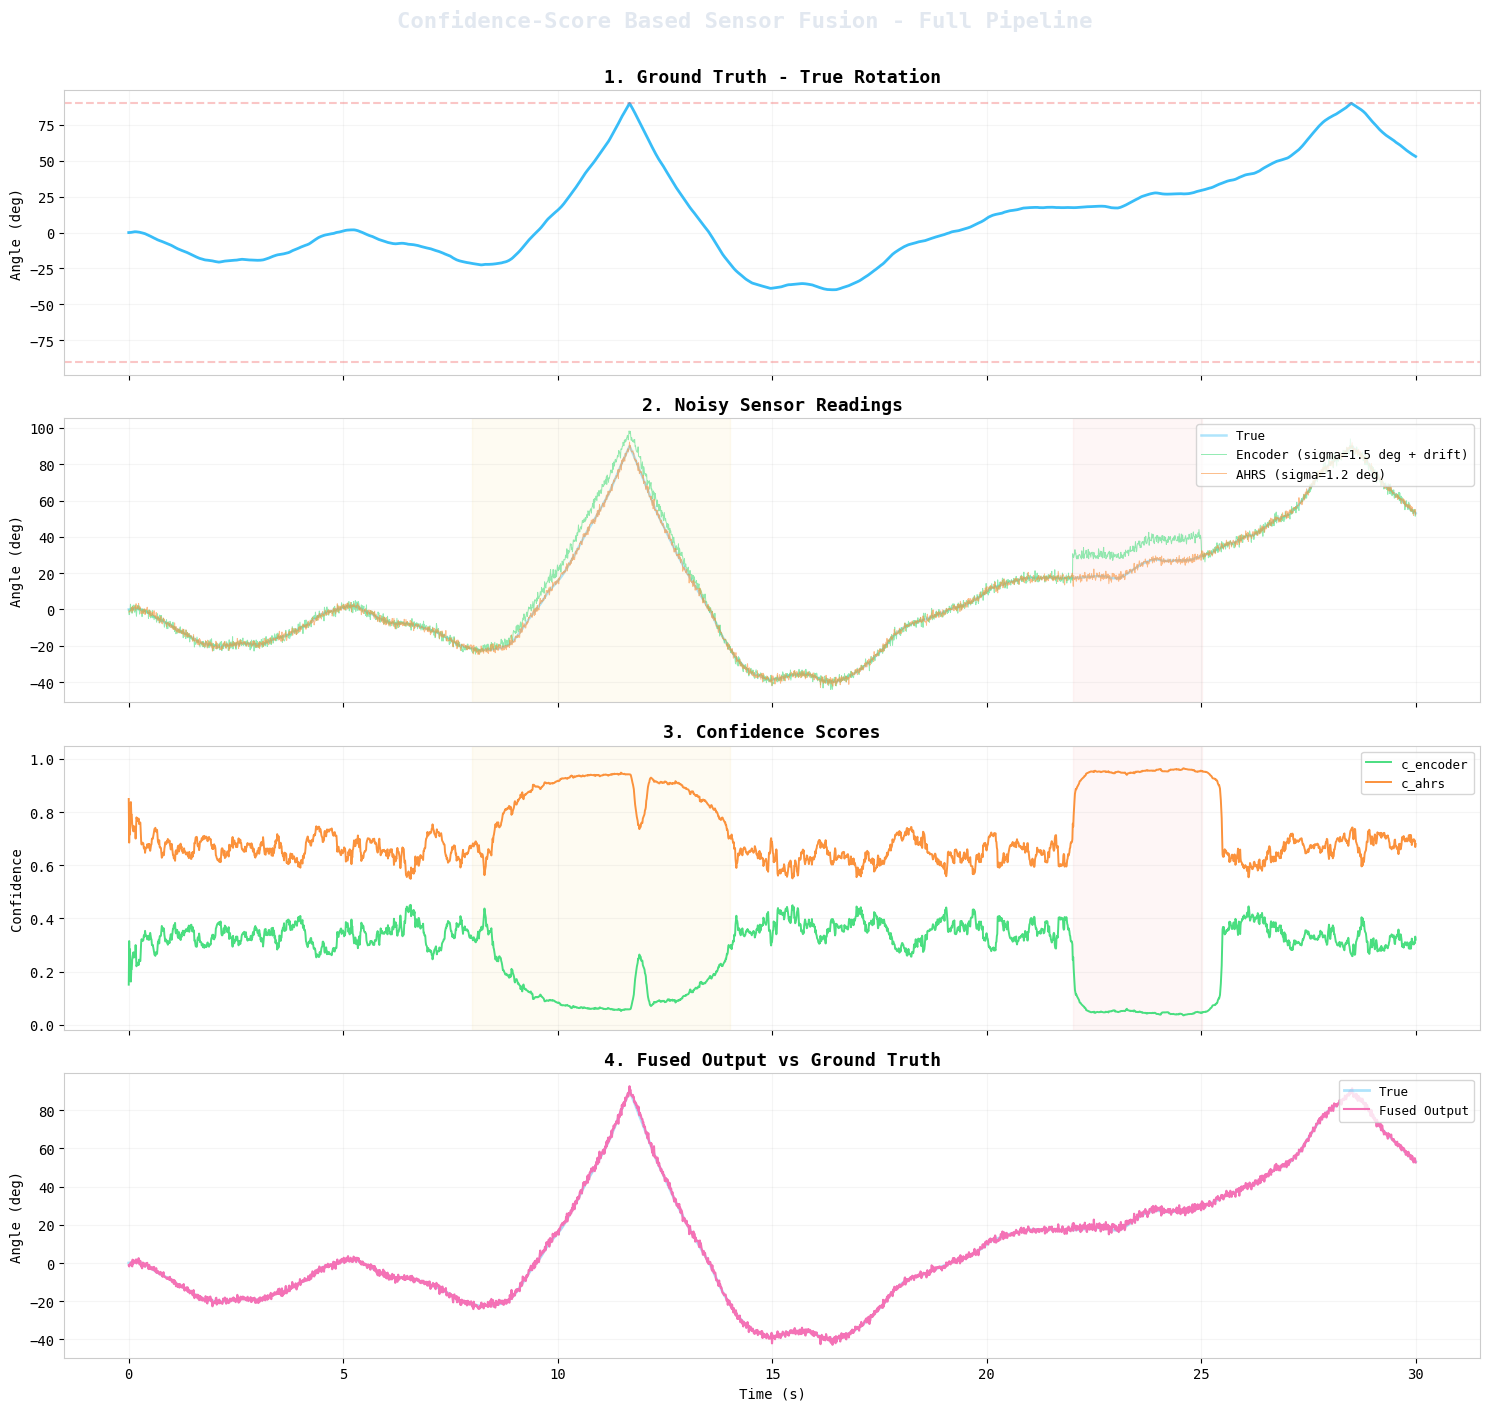

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(15, 14), sharex=True)

# -- Panel 1: Ground truth
axes[0].plot(t, theta_true, color='#38bdf8', lw=2)
axes[0].axhline(y= 90, color='#ef4444', ls='--', alpha=0.3)
axes[0].axhline(y=-90, color='#ef4444', ls='--', alpha=0.3)
axes[0].set_title('1. Ground Truth - True Rotation', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Angle (deg)'); axes[0].grid(alpha=0.12)

# -- Panel 2: Noisy sensor readings
axes[1].plot(t, theta_true, color='#38bdf8', lw=1.8, alpha=0.4, label='True')
axes[1].plot(t, theta_enc,  color='#4ade80', lw=0.7, alpha=0.6,
             label=f'Encoder (sigma={sigma_enc} deg + drift)')
axes[1].plot(t, theta_ahrs, color='#fb923c', lw=0.7, alpha=0.6,
             label=f'AHRS (sigma={sigma_ahrs} deg)')
axes[1].axvspan(t[800],  t[1400], alpha=0.06, color='#fbbf24')
axes[1].axvspan(t[2200], t[2500], alpha=0.06, color='#f87171')
axes[1].set_title('2. Noisy Sensor Readings', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Angle (deg)')
axes[1].legend(loc='upper right', fontsize=9); axes[1].grid(alpha=0.12)

# -- Panel 3: Confidence scores
axes[2].plot(t, c_enc,  color='#4ade80', lw=1.4, label='c_encoder')
axes[2].plot(t, c_ahrs, color='#fb923c', lw=1.4, label='c_ahrs')
axes[2].axvspan(t[800],  t[1400], alpha=0.06, color='#fbbf24')
axes[2].axvspan(t[2200], t[2500], alpha=0.06, color='#f87171')
axes[2].set_title('3. Confidence Scores', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Confidence'); axes[2].set_ylim(-0.02, 1.05)
axes[2].legend(loc='upper right', fontsize=9); axes[2].grid(alpha=0.12)

# -- Panel 4: Fused output
axes[3].plot(t, theta_true,  color='#38bdf8', lw=2, alpha=0.4, label='True')
axes[3].plot(t, theta_fused, color='#f472b6', lw=1.5, label='Fused Output')
axes[3].fill_between(t, theta_true, theta_fused, alpha=0.12, color='#f472b6')
axes[3].set_title('4. Fused Output vs Ground Truth', fontsize=13, fontweight='bold')
axes[3].set_xlabel('Time (s)'); axes[3].set_ylabel('Angle (deg)')
axes[3].legend(loc='upper right', fontsize=9); axes[3].grid(alpha=0.12)

fig.suptitle('Confidence-Score Based Sensor Fusion - Full Pipeline',
             fontsize=16, fontweight='bold', y=1.005, color='#e2e8f0')
plt.tight_layout()
plt.show()


---
## 6. Accuracy Analysis Over Time

To understand **how the fusion quality evolves** during operation, we compute
**rolling (windowed) accuracy metrics** for each signal against ground truth.

This reveals:
- How the fused output reacts to encoder **drift events** (highlighted regions)
- Whether the fusion maintains consistent accuracy or degrades in certain conditions
- The instantaneous error magnitude at every timestep

### Plots
1. **Instantaneous Absolute Error** — per-sample |estimated - true| for all three signals
2. **Rolling RMSE** — windowed RMS error showing local accuracy trends
3. **Rolling R-squared** — windowed coefficient of determination (1.0 = perfect tracking)


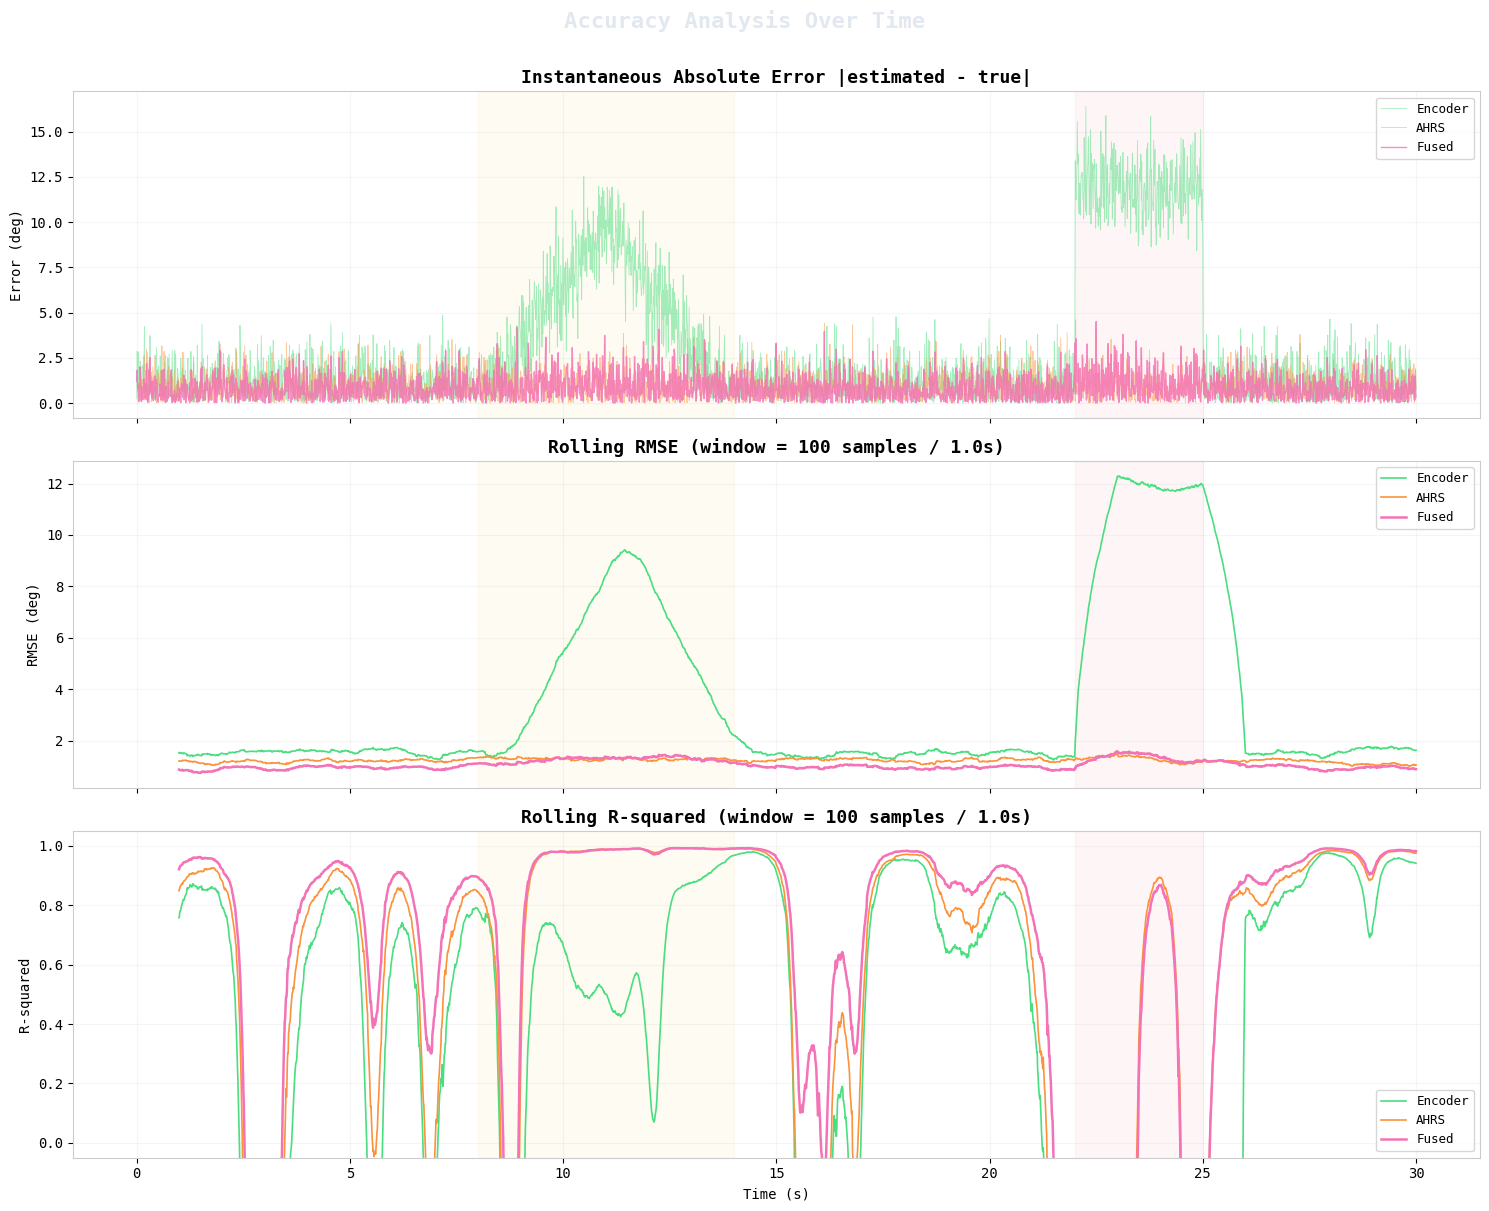

Accuracy window: 100 samples (1.0s)
Fused signal has lowest rolling RMSE for 2323/3000 samples (77.4% of the time)


In [6]:
# ══════════════════════════════════════════════════════════════════════════
#  ROLLING ACCURACY METRICS
# ══════════════════════════════════════════════════════════════════════════

ACCURACY_WINDOW = 100  # samples (= 1.0 s at 100 Hz)

def rolling_rmse(true, estimated, window):
    """Compute rolling RMSE with a causal sliding window."""
    n = len(true)
    result = np.full(n, np.nan)
    for i in range(window - 1, n):
        start = i - window + 1
        err = estimated[start:i+1] - true[start:i+1]
        result[i] = np.sqrt(np.mean(err**2))
    return result

def rolling_r2(true, estimated, window):
    """Compute rolling R-squared with a causal sliding window."""
    n = len(true)
    result = np.full(n, np.nan)
    for i in range(window - 1, n):
        start = i - window + 1
        seg_true = true[start:i+1]
        seg_est  = estimated[start:i+1]
        ss_res = np.sum((seg_est - seg_true)**2)
        ss_tot = np.sum((seg_true - np.mean(seg_true))**2)
        result[i] = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return result

# Compute instantaneous absolute errors
abs_err_enc   = np.abs(theta_enc   - theta_true)
abs_err_ahrs  = np.abs(theta_ahrs  - theta_true)
abs_err_fused = np.abs(theta_fused  - theta_true)

# Compute rolling metrics
roll_rmse_enc   = rolling_rmse(theta_true, theta_enc,   ACCURACY_WINDOW)
roll_rmse_ahrs  = rolling_rmse(theta_true, theta_ahrs,  ACCURACY_WINDOW)
roll_rmse_fused = rolling_rmse(theta_true, theta_fused, ACCURACY_WINDOW)

roll_r2_enc   = rolling_r2(theta_true, theta_enc,   ACCURACY_WINDOW)
roll_r2_ahrs  = rolling_r2(theta_true, theta_ahrs,  ACCURACY_WINDOW)
roll_r2_fused = rolling_r2(theta_true, theta_fused, ACCURACY_WINDOW)

# ── Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# -- Panel 1: Instantaneous absolute error
axes[0].plot(t, abs_err_enc,   color='#4ade80', lw=0.6, alpha=0.5, label='Encoder')
axes[0].plot(t, abs_err_ahrs,  color='#fb923c', lw=0.6, alpha=0.5, label='AHRS')
axes[0].plot(t, abs_err_fused, color='#f472b6', lw=1.0, alpha=0.8, label='Fused')
axes[0].axvspan(t[800],  t[1400], alpha=0.06, color='#fbbf24')
axes[0].axvspan(t[2200], t[2500], alpha=0.06, color='#f87171')
axes[0].set_title('Instantaneous Absolute Error |estimated - true|',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Error (deg)')
axes[0].legend(loc='upper right', fontsize=9); axes[0].grid(alpha=0.12)

# -- Panel 2: Rolling RMSE
axes[1].plot(t, roll_rmse_enc,   color='#4ade80', lw=1.2, label='Encoder')
axes[1].plot(t, roll_rmse_ahrs,  color='#fb923c', lw=1.2, label='AHRS')
axes[1].plot(t, roll_rmse_fused, color='#f472b6', lw=1.8, label='Fused')
axes[1].axvspan(t[800],  t[1400], alpha=0.06, color='#fbbf24')
axes[1].axvspan(t[2200], t[2500], alpha=0.06, color='#f87171')
axes[1].set_title(f'Rolling RMSE (window = {ACCURACY_WINDOW} samples / {ACCURACY_WINDOW*dt:.1f}s)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('RMSE (deg)')
axes[1].legend(loc='upper right', fontsize=9); axes[1].grid(alpha=0.12)

# -- Panel 3: Rolling R-squared
axes[2].plot(t, roll_r2_enc,   color='#4ade80', lw=1.2, label='Encoder')
axes[2].plot(t, roll_r2_ahrs,  color='#fb923c', lw=1.2, label='AHRS')
axes[2].plot(t, roll_r2_fused, color='#f472b6', lw=1.8, label='Fused')
axes[2].axvspan(t[800],  t[1400], alpha=0.06, color='#fbbf24')
axes[2].axvspan(t[2200], t[2500], alpha=0.06, color='#f87171')
axes[2].set_title(f'Rolling R-squared (window = {ACCURACY_WINDOW} samples / {ACCURACY_WINDOW*dt:.1f}s)',
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel('Time (s)'); axes[2].set_ylabel('R-squared')
axes[2].set_ylim(-0.05, 1.05)
axes[2].legend(loc='lower right', fontsize=9); axes[2].grid(alpha=0.12)

fig.suptitle('Accuracy Analysis Over Time',
             fontsize=16, fontweight='bold', y=1.005, color='#e2e8f0')
plt.tight_layout()
plt.show()

# Summary
print(f'Accuracy window: {ACCURACY_WINDOW} samples ({ACCURACY_WINDOW*dt:.1f}s)')
print(f'Fused signal has lowest rolling RMSE for '
      f'{np.nansum((roll_rmse_fused < roll_rmse_enc) & (roll_rmse_fused < roll_rmse_ahrs))}/{N} '
      f'samples ({np.nansum((roll_rmse_fused < roll_rmse_enc) & (roll_rmse_fused < roll_rmse_ahrs))/N*100:.1f}% of the time)')


---
## 7. Quality Score Card

A comprehensive summary comparing the quality of each signal against ground truth.

| Metric | Definition | Purpose |
|--------|-----------|--------|
| **RMSE** | $\sqrt{\frac{1}{N}\sum(\hat{\theta}-\theta)^2}$ | Overall average error magnitude |
| **MAE** | $\frac{1}{N}\sum|\hat{\theta}-\theta|$ | Average absolute deviation |
| **Max Error** | $\max|\hat{\theta}-\theta|$ | Worst-case instantaneous error |
| **R-squared** | $1 - \frac{\sum(\hat{\theta}-\theta)^2}{\sum(\theta-\bar{\theta})^2}$ | Variance explained (1 = perfect) |
| **SNR (dB)** | $10\log_{10}\frac{\sigma^2_{signal}}{\sigma^2_{error}}$ | Signal-to-noise ratio |

The **"Fused Improvement"** column shows how much the fusion improves over the
**best individual sensor** for each metric.

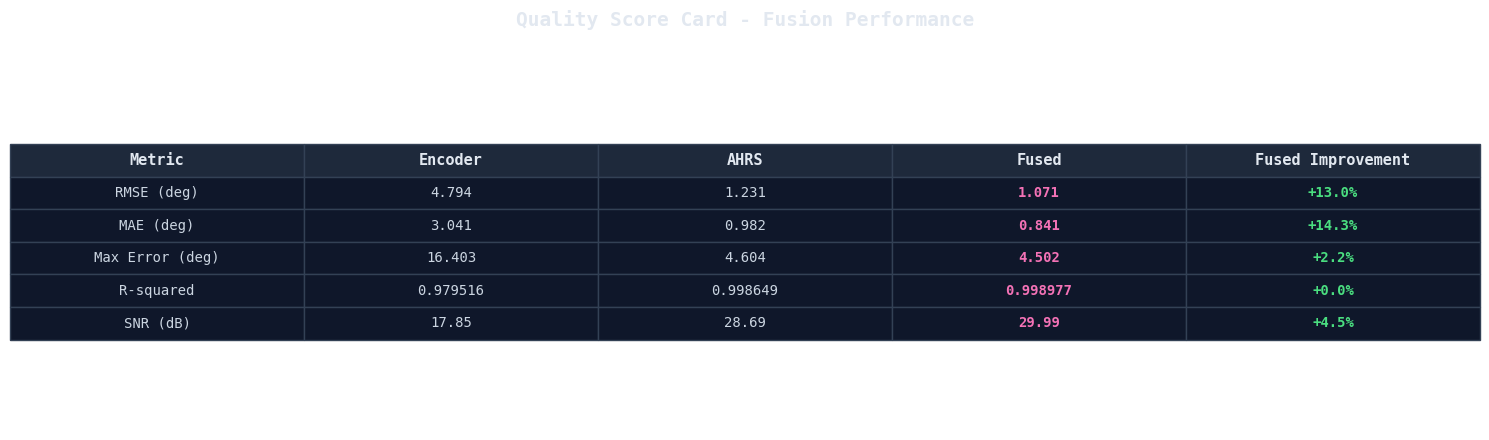

  CONFIDENCE-SCORE SENSOR FUSION - QUALITY ASSESSMENT
  Duration          : 30s  |  Samples: 3000  |  dt: 0.01s
  Encoder noise     : sigma = 1.5 deg  (+ drift events)
  AHRS noise        : sigma = 1.2 deg
  Rolling window    : 50 samples (0.5s)
  --------------------------------------------------------------------
  Metric                  Encoder       AHRS      Fused      vs Best
  --------------------------------------------------------------------
  RMSE (deg)                4.794      1.231      1.071       +13.0%
  MAE (deg)                 3.041      0.982      0.841       +14.3%
  Max Error (deg)          16.403      4.604      4.502        +2.2%
  R-squared              0.979516   0.998649   0.998977        +0.0%
  SNR (dB)                  17.85      28.69      29.99        +4.5%
  --------------------------------------------------------------------

  FUSION QUALITY VERDICT:
    [PASS] Fused RMSE (1.071 deg) is BETTER than best raw sensor (1.231 deg)
    [PASS] Fused R-squa

'd:\\Reza Fauzan\\Anduril Industries\\simulation\\sim_timeseries_20260904_200120.csv'

In [8]:
# ══════════════════════════════════════════════════════════════════════════
#  QUALITY METRICS FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════

def compute_metrics(true, estimated, label):
    """Compute a full suite of quality metrics for a sensor/fused signal."""
    error = estimated - true
    abs_error = np.abs(error)

    rmse = np.sqrt(np.mean(error**2))
    mae  = np.mean(abs_error)
    max_err = np.max(abs_error)

    # R-squared (coefficient of determination)
    ss_res = np.sum(error**2)
    ss_tot = np.sum((true - np.mean(true))**2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float('nan')

    # Signal-to-Noise Ratio (dB)
    signal_var = np.var(true)
    error_var  = np.var(error)
    snr_db = 10.0 * np.log10(signal_var / error_var) if error_var > 0 else float('inf')

    return {
        'label':     label,
        'rmse':      rmse,
        'mae':       mae,
        'max_error': max_err,
        'r2':        r2,
        'snr_db':    snr_db,
    }

def improvement_str(raw_val, fused_val, lower_better=True):
    """Format an improvement percentage string."""
    if lower_better:
        pct = (1.0 - fused_val / raw_val) * 100.0 if raw_val != 0 else 0.0
    else:
        pct = (fused_val / raw_val - 1.0) * 100.0 if raw_val != 0 else 0.0
    sign = '+' if pct >= 0 else ''
    return f'{sign}{pct:.1f}%'

# Compute metrics
m_enc   = compute_metrics(theta_true, theta_enc,   'Encoder')
m_ahrs  = compute_metrics(theta_true, theta_ahrs,  'AHRS')
m_fused = compute_metrics(theta_true, theta_fused, 'Fused')

# Best raw sensor per metric
best_rmse = min(m_enc['rmse'], m_ahrs['rmse'])
best_mae  = min(m_enc['mae'],  m_ahrs['mae'])
best_max  = min(m_enc['max_error'], m_ahrs['max_error'])
best_r2   = max(m_enc['r2'],   m_ahrs['r2'])
best_snr  = max(m_enc['snr_db'], m_ahrs['snr_db'])

# ══════════════════════════════════════════════════════════════════════════
#  VISUAL SCORE CARD
# ══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(15, 4.5))
ax.axis('off')

col_labels = ['Metric', 'Encoder', 'AHRS', 'Fused', 'Fused Improvement']
row_data = [
    ['RMSE (deg)',      f"{m_enc['rmse']:.3f}",      f"{m_ahrs['rmse']:.3f}",      f"{m_fused['rmse']:.3f}",      improvement_str(best_rmse, m_fused['rmse'])],
    ['MAE (deg)',       f"{m_enc['mae']:.3f}",       f"{m_ahrs['mae']:.3f}",       f"{m_fused['mae']:.3f}",       improvement_str(best_mae, m_fused['mae'])],
    ['Max Error (deg)', f"{m_enc['max_error']:.3f}", f"{m_ahrs['max_error']:.3f}", f"{m_fused['max_error']:.3f}", improvement_str(best_max, m_fused['max_error'])],
    ['R-squared',       f"{m_enc['r2']:.6f}",       f"{m_ahrs['r2']:.6f}",       f"{m_fused['r2']:.6f}",       improvement_str(best_r2, m_fused['r2'], lower_better=False)],
    ['SNR (dB)',        f"{m_enc['snr_db']:.2f}",    f"{m_ahrs['snr_db']:.2f}",    f"{m_fused['snr_db']:.2f}",    improvement_str(best_snr, m_fused['snr_db'], lower_better=False)],
]

table = ax.table(
    cellText=row_data, colLabels=col_labels,
    cellLoc='center', loc='center',
    colColours=['#1e293b'] * 5
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.0, 1.8)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#334155')
    if row == 0:
        cell.set_text_props(color='#e2e8f0', fontweight='bold', fontsize=11)
        cell.set_facecolor('#1e293b')
    else:
        cell.set_facecolor('#0f172a')
        cell.set_text_props(color='#cbd5e1', fontsize=10)
        if col == 3:
            cell.set_text_props(color='#f472b6', fontweight='bold', fontsize=10)
        if col == 4:
            text = cell.get_text().get_text()
            if text.startswith('+'):
                cell.set_text_props(color='#4ade80', fontweight='bold', fontsize=10)
            elif text.startswith('-'):
                cell.set_text_props(color='#ef4444', fontweight='bold', fontsize=10)

ax.set_title('Quality Score Card - Fusion Performance',
             fontsize=14, fontweight='bold', pad=20, color='#e2e8f0')
plt.tight_layout()
plt.show()

# ── Console Summary ──────────────────────────────────────────────────────
print('=' * 72)
print('  CONFIDENCE-SCORE SENSOR FUSION - QUALITY ASSESSMENT')
print('=' * 72)
print(f'  Duration          : {T:.0f}s  |  Samples: {N}  |  dt: {dt}s')
print(f'  Encoder noise     : sigma = {sigma_enc} deg  (+ drift events)')
print(f'  AHRS noise        : sigma = {sigma_ahrs} deg')
print(f'  Rolling window    : {WINDOW} samples ({WINDOW*dt:.1f}s)')
print(f'  ' + '-' * 68)
print(f'  {"Metric":<20s} {"Encoder":>10s} {"AHRS":>10s} {"Fused":>10s} {"vs Best":>12s}')
print(f'  ' + '-' * 68)
print(f'  {"RMSE (deg)":<20s} {m_enc["rmse"]:>10.3f} {m_ahrs["rmse"]:>10.3f} {m_fused["rmse"]:>10.3f} {improvement_str(best_rmse, m_fused["rmse"]):>12s}')
print(f'  {"MAE (deg)":<20s} {m_enc["mae"]:>10.3f} {m_ahrs["mae"]:>10.3f} {m_fused["mae"]:>10.3f} {improvement_str(best_mae, m_fused["mae"]):>12s}')
print(f'  {"Max Error (deg)":<20s} {m_enc["max_error"]:>10.3f} {m_ahrs["max_error"]:>10.3f} {m_fused["max_error"]:>10.3f} {improvement_str(best_max, m_fused["max_error"]):>12s}')
print(f'  {"R-squared":<20s} {m_enc["r2"]:>10.6f} {m_ahrs["r2"]:>10.6f} {m_fused["r2"]:>10.6f} {improvement_str(best_r2, m_fused["r2"], lower_better=False):>12s}')
print(f'  {"SNR (dB)":<20s} {m_enc["snr_db"]:>10.2f} {m_ahrs["snr_db"]:>10.2f} {m_fused["snr_db"]:>10.2f} {improvement_str(best_snr, m_fused["snr_db"], lower_better=False):>12s}')
print(f'  ' + '-' * 68)
print(f'\n  FUSION QUALITY VERDICT:')
if m_fused['rmse'] < best_rmse:
    print(f'    [PASS] Fused RMSE ({m_fused["rmse"]:.3f} deg) is BETTER than best raw sensor ({best_rmse:.3f} deg)')
else:
    print(f'    [WARN] Fused RMSE ({m_fused["rmse"]:.3f} deg) is WORSE than best raw sensor ({best_rmse:.3f} deg)')
if m_fused['r2'] > best_r2:
    print(f'    [PASS] Fused R-squared ({m_fused["r2"]:.6f}) is BETTER than best raw sensor ({best_r2:.6f})')
else:
    print(f'    [WARN] Fused R-squared ({m_fused["r2"]:.6f}) is WORSE than best raw sensor ({best_r2:.6f})')
if m_fused['snr_db'] > best_snr:
    print(f'    [PASS] Fused SNR ({m_fused["snr_db"]:.2f} dB) is BETTER than best raw sensor ({best_snr:.2f} dB)')
else:
    print(f'    [WARN] Fused SNR ({m_fused["snr_db"]:.2f} dB) is WORSE than best raw sensor ({best_snr:.2f} dB)')
print('=' * 72)

from csv_logger import export_timeseries_to_csv

export_timeseries_to_csv(
    t=t,
    theta_true=theta_true,
    theta_enc=theta_enc,
    theta_ahrs=theta_ahrs,
    theta_fused=theta_fused,
    conf_enc=c_enc,
    conf_ahrs=c_ahrs,
    err_enc=err_enc,
    err_ahrs=err_ahrs,
    err_fused=err_fused,
)

